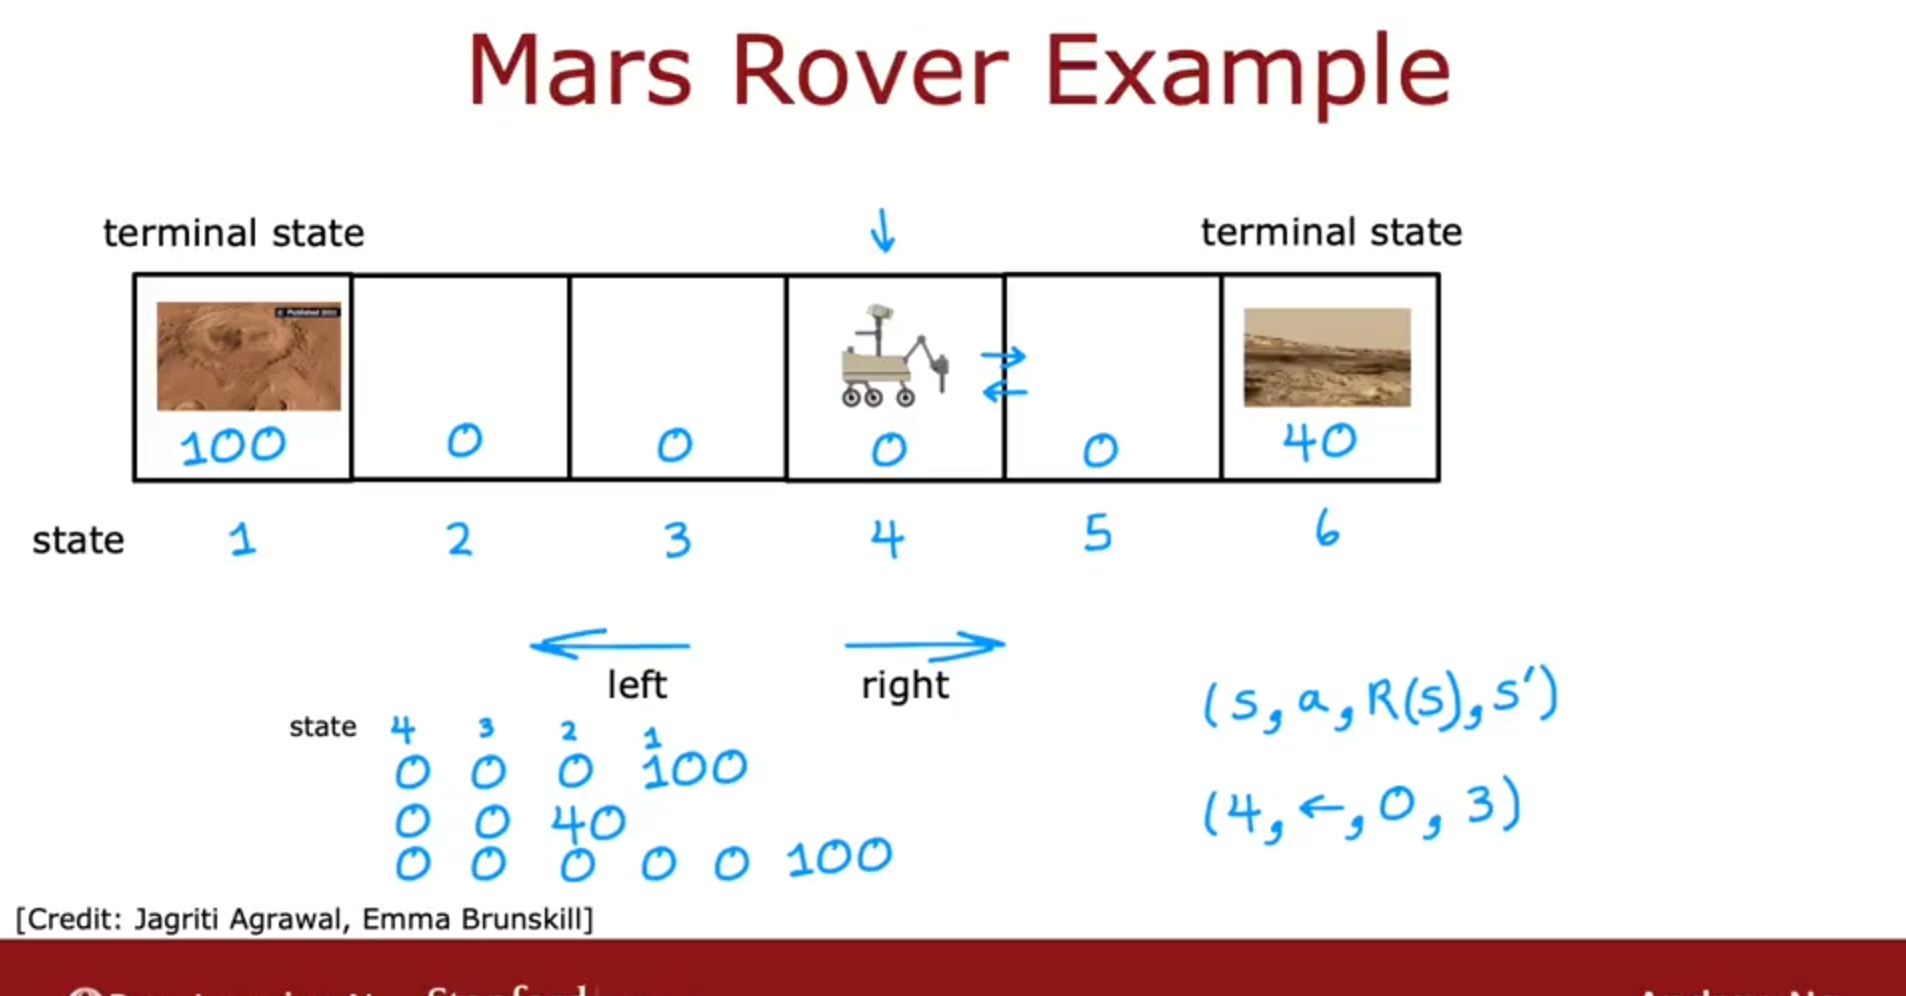

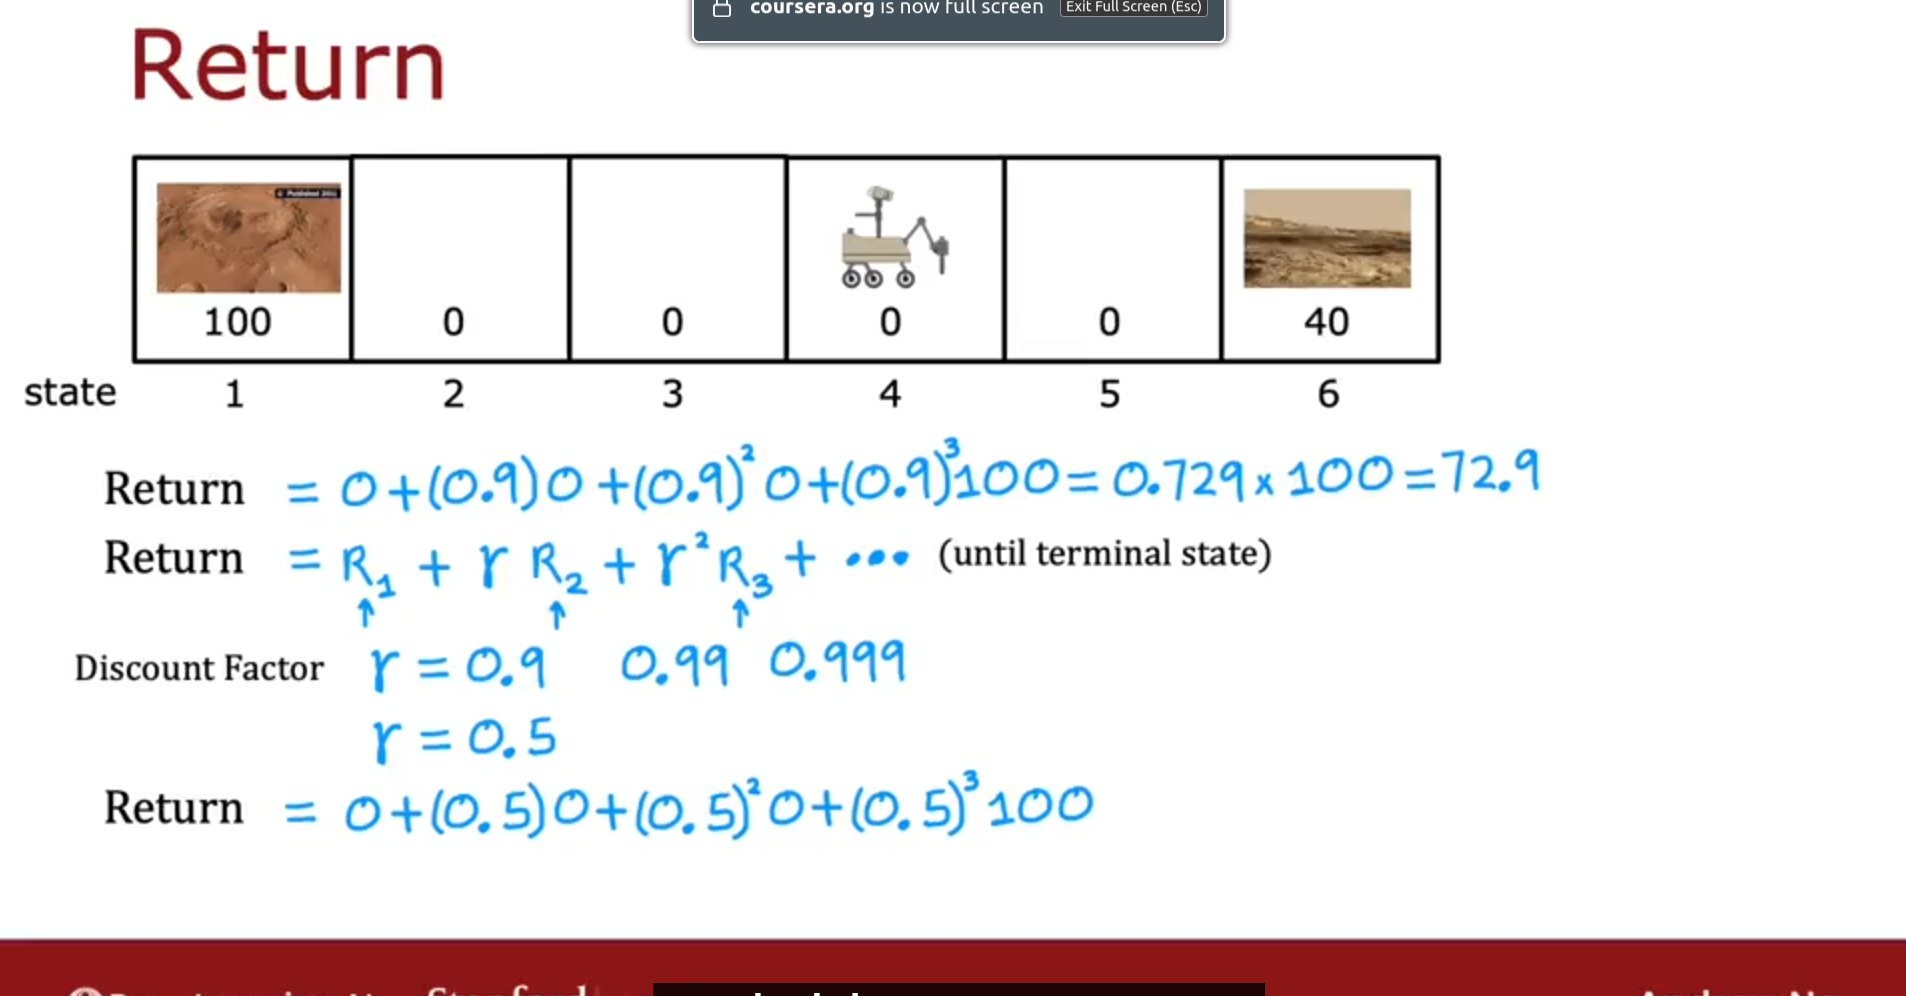

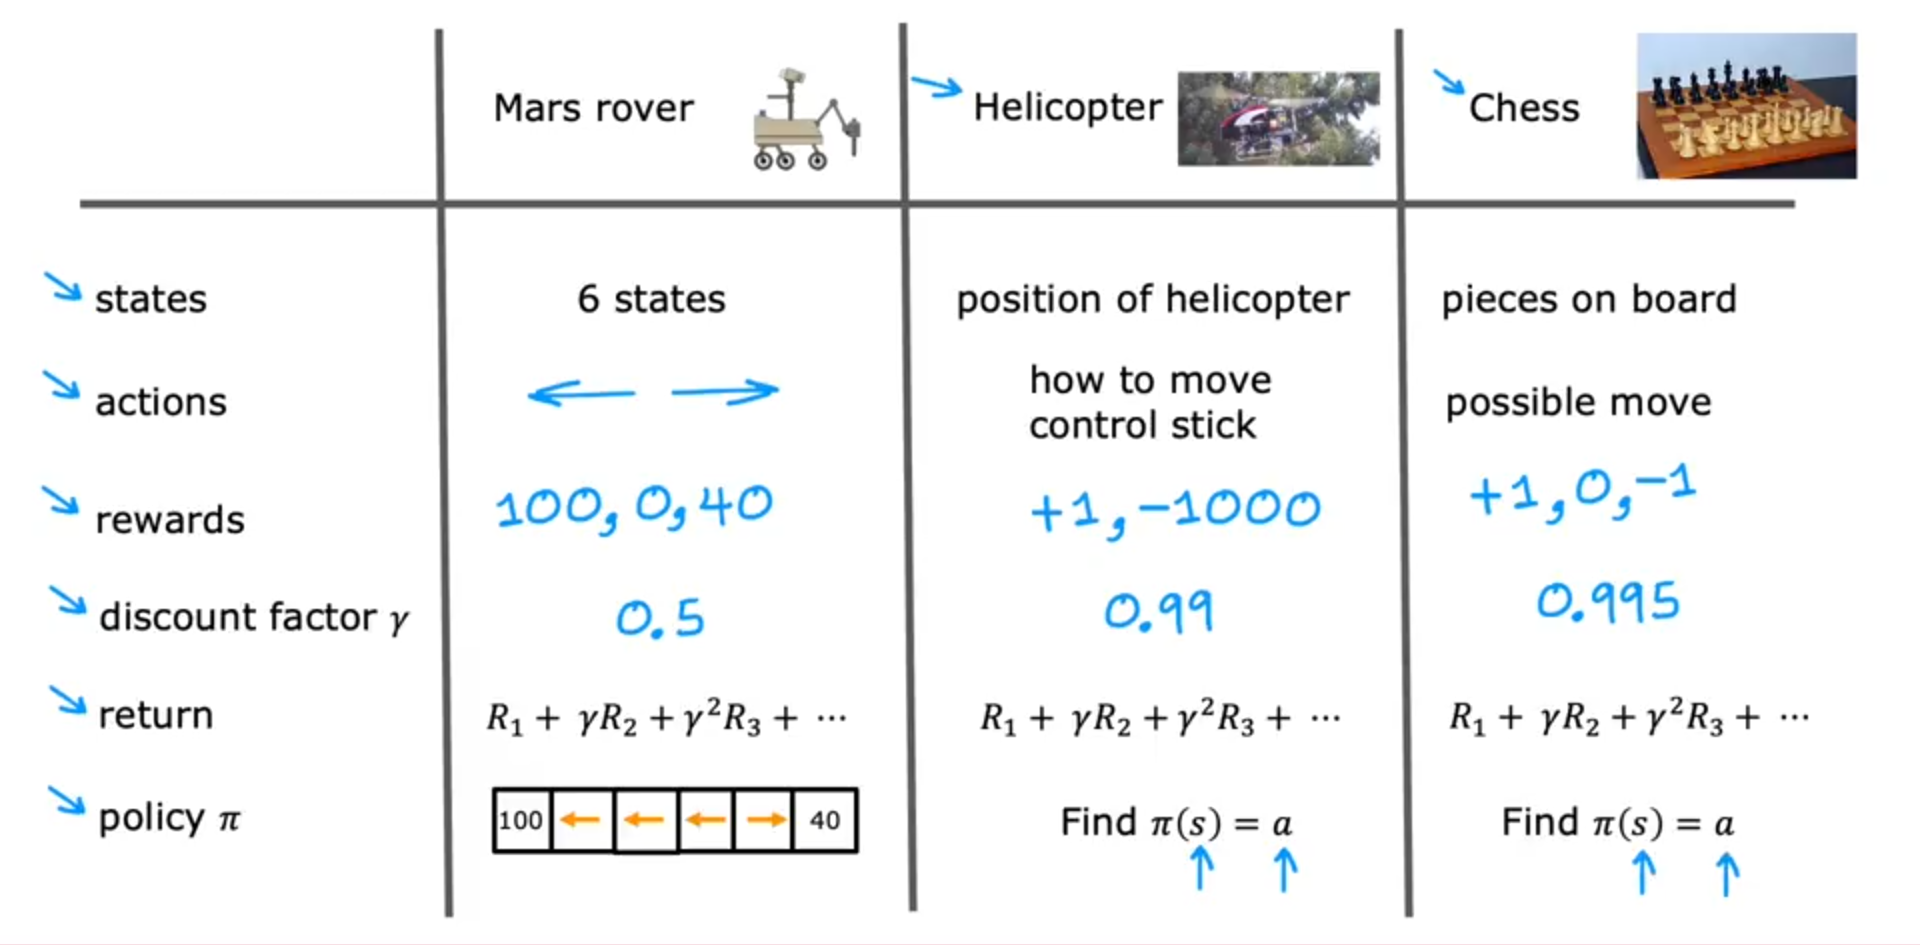

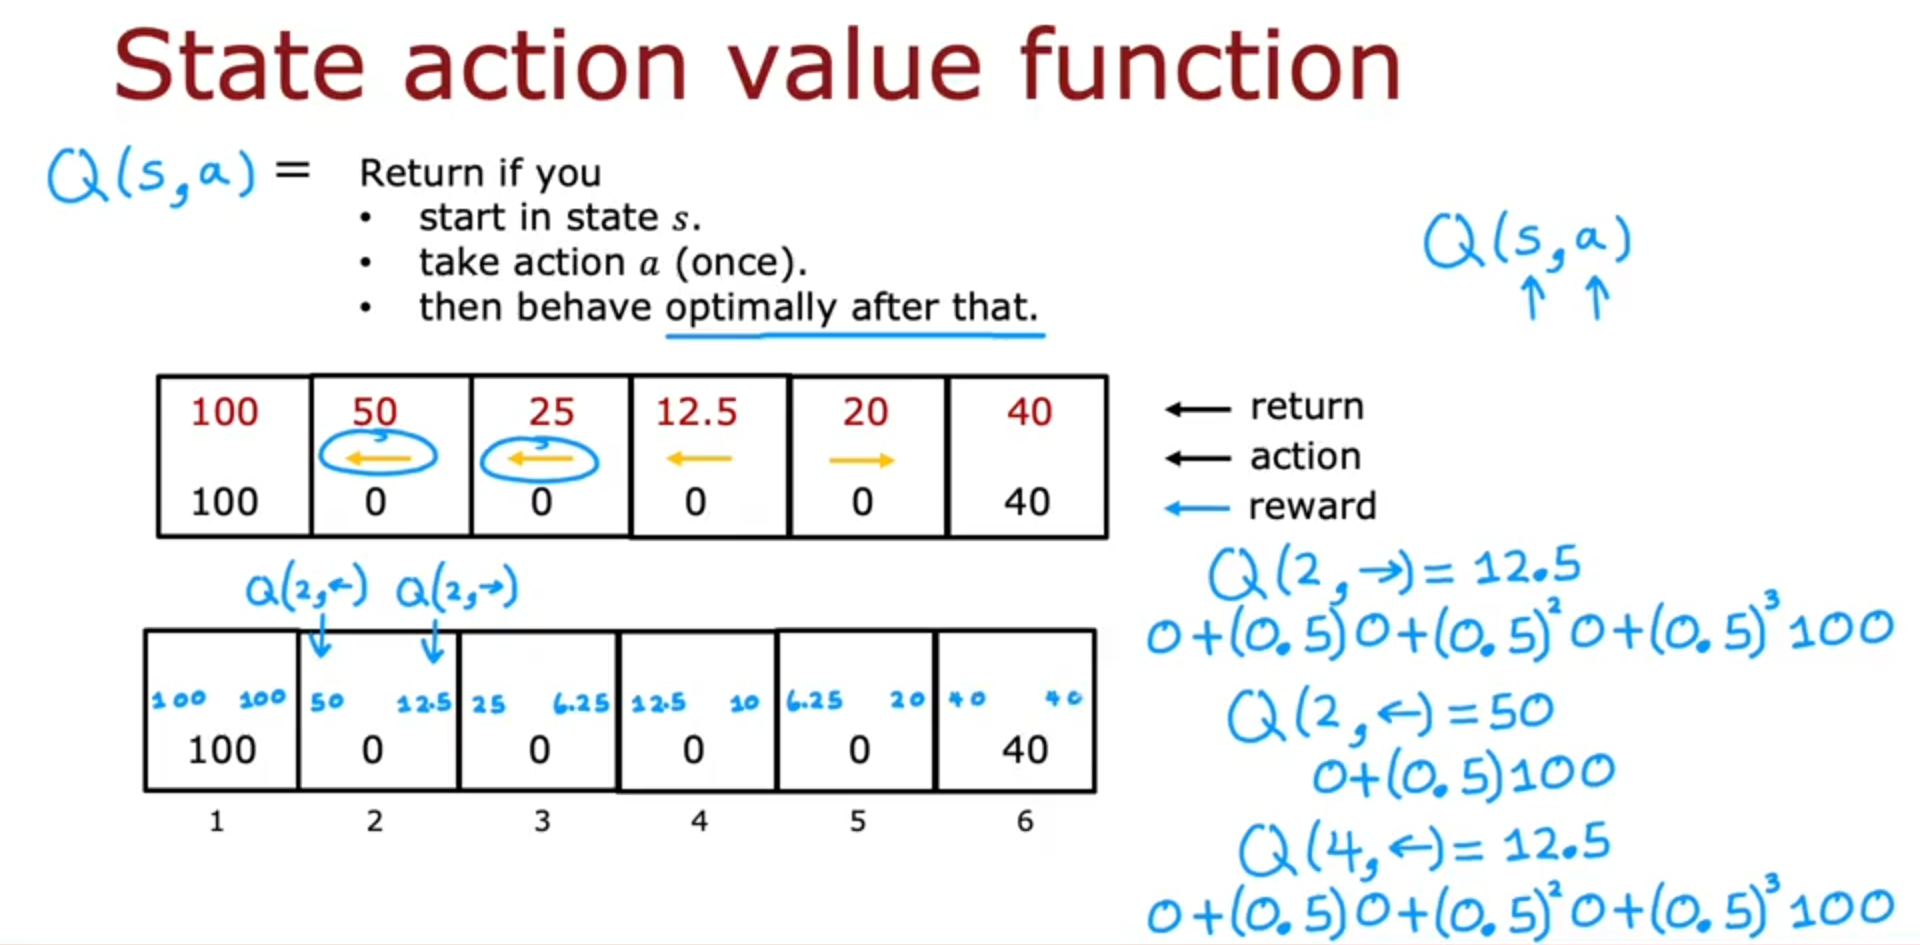

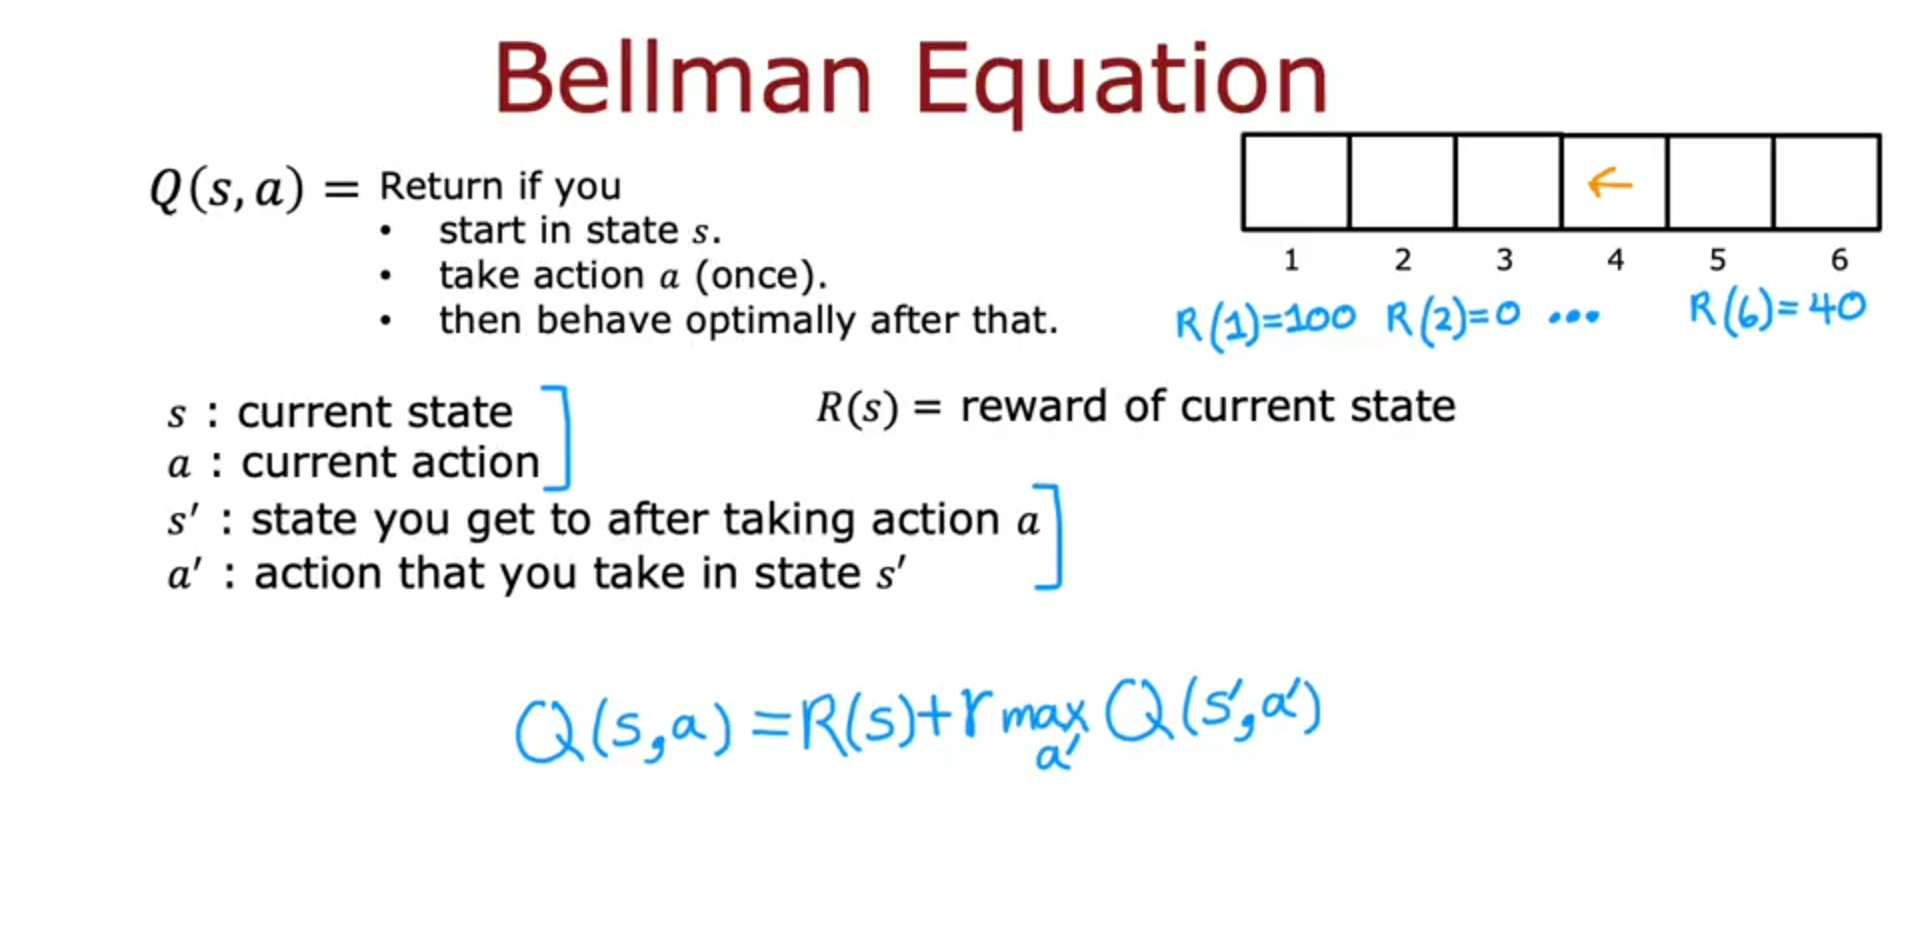

In [3]:
import numpy as np

def update_q_value(q_table, state, action, reward, next_state, learning_rate, gamma):
    """
    Bellman Denklemine dayalı Q-Value güncelleme fonksiyonu.
    
    Argümanlar:
        q_table: Her durum-aksiyon çifti için puanların tutulduğu tablo.
        state: Şu anki durum (örn: kavşaktaki konumu).
        action: Yapılan hamle (örn: sağa dönmek).
        reward: Bu hamle sonucunda alınan anlık ödül (R).
        next_state: Hamle sonrası geçilen yeni durum (s').
        learning_rate (alpha): Yeni bilgiyi ne kadar hızlı öğreneceğimiz (0-1).
        gamma: İskonto faktörü; gelecek ödüllere verilen önem.
    """
    
    # 1. Gelecek Tahmini: Bir sonraki durumda yapılabilecek en iyi hareketin puanını bul (max Q(s', a'))
    best_next_action_value = np.max(q_table[next_state])
    
    # 2. Bellman Hedefi: Mevcut ödül + Gelecekten gelen iskonto edilmiş puan
    bellman_target = reward + (gamma * best_next_action_value)
    
    # 3. Hata Payı (Temporal Difference): Hedef ile şu anki bilgi arasındaki fark
    td_error = bellman_target - q_table[state, action]
    
    # 4. Güncelleme: Mevcut bilgiyi hata payı ve öğrenme oranı kadar düzelt
    # Formül: Q(s,a) = Q(s,a) + alpha * [R + gamma * max(Q(s',a')) - Q(s,a)]
    q_table[state, action] += learning_rate * td_error
    
    return q_table